# <지능정보시스템: 중간고사 대체 과제>

## 201801539 김영화
---

## csv와 html 내의 테이블 데이터 읽고 그래프 그리기

In [89]:
# 라이브러리
import pandas as pd
import re
import matplotlib.pyplot as plt
import csv
import numpy as np

### 1번. *csv 파일* 읽기 & 그래프 그리기
#### 1. 데이터 설명
- [출처URL](https://jumin.mois.go.kr/#) : 행정안전부 > 주민등록 인구통계 > 주민등록 인구 기타현황 > **지역별 인구증감**
- 행정안전부 사이트의 지역별 인구증감 데이터 중 경기도 데이터를 선택하였다.
- 검색기간이 최대 36개월이라 2019년 09월 부터 2021년 09월로 기간을 최대한으로 설정하였다.

#### 2. 데이터 선택 이유
- 내가 살고 있는 '경기도 부천시'는 인구밀도가 높은 도시이다. 우리 지역의 인구가 계속 늘고 있는지 여부가 궁금해졌다. 언제 인구증감이 제일 큰지와 성별로 나눴을 때의 차이도 보고 싶다.
- **질문: 최근 36개월간, 내가 살고 있는 '경기도 부천시'의 인구가 증가하였을까? 인구증감이 가장 큰 시기(월)는 언제였을까? 그리고 인구증감을 성별으로 나눠서 보았을 때 차이도 궁금하다.**

#### 3. 데이터 전처리 내용
- 원본 csv파일인 '201909_202109_주민등록인구기타현황(인구증감)_checkStatExcelMobile.csv'은 숫자에 쉼표(,) 단위가 있어 이 파일을 불러오면 숫자가 'str' 형태로 나타난다. 이 문제를 해결하기 위해 엑셀에서 쉼표를 없앤 파일인 '인구증감.csv'를 새롭게 생성하여 사용하였다.
- 월별 인구증감만 필요하기 때문에 불필요한 열들은 `.drop()` 을 사용하여 제거하였다.   
이어서...

In [126]:
df = pd.read_csv('인구증감.csv', encoding='cp949', header=0, index_col=0)
for i in range(0, len(df.columns), 3):
    df = df.drop(df.iloc[:, i:(i+6)], axis=1)
df

,2019년09월_인구증감_남자인구수,2019년09월_인구증감_여자인구수,2019년09월_인구증감_계,2019년10월_인구증감_남자인구수,2019년10월_인구증감_여자인구수,2019년10월_인구증감_계,2019년11월_인구증감_남자인구수,2019년11월_인구증감_여자인구수,2019년11월_인구증감_계,2019년12월_인구증감_남자인구수,...,2021년06월_인구증감_계,2021년07월_인구증감_남자인구수,2021년07월_인구증감_여자인구수,2021년07월_인구증감_계,2021년08월_인구증감_남자인구수,2021년08월_인구증감_여자인구수,2021년08월_인구증감_계,2021년09월_인구증감_남자인구수,2021년09월_인구증감_여자인구수,2021년09월_인구증감_계
행정구역,,,,,,,,,,,,,,,,,,,,,
경기도 (4100000000),6822,6454,13276,5560,6133,11693,4112,5153,9265,5424,...,11778,5920,6259,12179,9097,8555,17652,6344,5421,11765
경기도 수원시 (4111000000),504,252,756,-577,-293,-870,-203,-167,-370,-287,...,-712,-386,-209,-595,-73,-123,-196,733,602,1335
경기도 수원시 장안구 (4111100000),43,-172,-129,-295,-306,-601,-220,-200,-420,-225,...,-434,-191,-138,-329,-53,-85,-138,1383,1336,2719
경기도 수원시 권선구 (4111300000),-128,-199,-327,-270,-179,-449,-149,-214,-363,-153,...,-176,-45,-6,-51,9,-63,-54,-227,-205,-432
경기도 수원시 팔달구 (4111500000),-219,-193,-412,-251,-260,-511,-148,-160,-308,-220,...,279,-2,77,75,25,65,90,-147,-216,-363
경기도 수원시 영통구 (4111700000),808,816,1624,239,452,691,314,407,721,311,...,-381,-148,-142,-290,-54,-40,-94,-276,-313,-589
경기도 성남시 (4113000000),-403,-402,-805,-652,-504,-1156,-294,-362,-656,-93,...,28,48,54,102,-1,176,175,-116,-55,-171
경기도 성남시 수정구 (4113100000),240,337,577,68,162,230,-62,-90,-152,-12,...,-856,-244,-278,-522,-287,-344,-631,-95,-95,-190
경기도 성남시 중원구 (4113300000),-238,-272,-510,-280,-217,-497,-117,-150,-267,-210,...,-445,-286,-292,-578,-239,-166,-405,-279,-225,-504


- '수원시, '수원시 장안구', '수원시 권선구', '수원시 팔달구' 같이 데이터에 시와 구가 함께 존재한다. 이를 큰 범위의 '시'만 보고 싶어 index의 길이를 기준으로 행을 제거하였다.
- '경기도 의정부시 (4115000000)'같이 index에 행정구역을 나타내는 숫자가 포함되어 있다. 필요 없으니 제거한다.

In [91]:
print(df.index[10])

경기도 의정부시 (4115000000)


In [92]:
len(df.index[10])

21

In [93]:
index_list = []
for i in range(len(df.index)):
    if len(df.index[i]) > 21:
        index_list.append(df.index[i])
df = df.drop(index_list)
index_list = []
for i in range(len(df.index)):
    index_list.append(re.sub("[12345667890()]", "", df.index[i]))
    
df.index = index_list
df

,2019년09월_인구증감_남자인구수,2019년09월_인구증감_여자인구수,2019년09월_인구증감_계,2019년10월_인구증감_남자인구수,2019년10월_인구증감_여자인구수,2019년10월_인구증감_계,2019년11월_인구증감_남자인구수,2019년11월_인구증감_여자인구수,2019년11월_인구증감_계,2019년12월_인구증감_남자인구수,...,2021년06월_인구증감_계,2021년07월_인구증감_남자인구수,2021년07월_인구증감_여자인구수,2021년07월_인구증감_계,2021년08월_인구증감_남자인구수,2021년08월_인구증감_여자인구수,2021년08월_인구증감_계,2021년09월_인구증감_남자인구수,2021년09월_인구증감_여자인구수,2021년09월_인구증감_계
경기도,6822,6454,13276,5560,6133,11693,4112,5153,9265,5424,...,11778,5920,6259,12179,9097,8555,17652,6344,5421,11765
경기도 수원시,504,252,756,-577,-293,-870,-203,-167,-370,-287,...,-712,-386,-209,-595,-73,-123,-196,733,602,1335
경기도 성남시,-403,-402,-805,-652,-504,-1156,-294,-362,-656,-93,...,28,48,54,102,-1,176,175,-116,-55,-171
경기도 의정부시,34,-31,3,-12,7,-5,22,-30,-8,-37,...,600,595,470,1065,374,411,785,102,87,189
경기도 안양시,-403,-286,-689,-329,-463,-792,-447,-260,-707,-1030,...,-847,-501,-442,-943,-225,-244,-469,-177,-240,-417
경기도 부천시,-565,-493,-1058,-800,-717,-1517,-555,-335,-890,-395,...,-483,-355,-318,-673,-292,-218,-510,-302,-174,-476
경기도 광명시,-374,-320,-694,-602,-582,-1184,-436,-441,-877,-316,...,110,-167,-125,-292,-178,-47,-225,-205,-235,-440
경기도 평택시,983,821,1804,997,911,1908,953,747,1700,973,...,1770,1008,694,1702,1714,1194,2908,1718,1221,2939
경기도 동두천시,-67,-31,-98,3,26,29,-57,-105,-162,30,...,62,49,44,93,-48,15,-33,34,31,65
경기도 안산시,-698,-532,-1230,-963,-870,-1833,-547,-511,-1058,-440,...,-440,-301,-136,-437,-49,-152,-201,-127,-80,-207


- columns도 보기 좋게 YYMM(남/여/합)으로 나타내었다.

In [94]:
col_list = []
ind = []
for i in range(len(df.columns)):
    if i % 3 == 0:
        ind.append(df.columns[i][2:4]+ df.columns[i][5:7])
        col_list.append(df.columns[i][2:4]+ df.columns[i][5:7] +'남') 
    elif i % 3 == 1:
        col_list.append(df.columns[i][2:4]+ df.columns[i][5:7] +'여')
    else:
        col_list.append(df.columns[i][2:4]+ df.columns[i][5:7] +'합')
df.columns = col_list
df

,1909남,1909여,1909합,1910남,1910여,1910합,1911남,1911여,1911합,1912남,...,2106합,2107남,2107여,2107합,2108남,2108여,2108합,2109남,2109여,2109합
경기도,6822,6454,13276,5560,6133,11693,4112,5153,9265,5424,...,11778,5920,6259,12179,9097,8555,17652,6344,5421,11765
경기도 수원시,504,252,756,-577,-293,-870,-203,-167,-370,-287,...,-712,-386,-209,-595,-73,-123,-196,733,602,1335
경기도 성남시,-403,-402,-805,-652,-504,-1156,-294,-362,-656,-93,...,28,48,54,102,-1,176,175,-116,-55,-171
경기도 의정부시,34,-31,3,-12,7,-5,22,-30,-8,-37,...,600,595,470,1065,374,411,785,102,87,189
경기도 안양시,-403,-286,-689,-329,-463,-792,-447,-260,-707,-1030,...,-847,-501,-442,-943,-225,-244,-469,-177,-240,-417
경기도 부천시,-565,-493,-1058,-800,-717,-1517,-555,-335,-890,-395,...,-483,-355,-318,-673,-292,-218,-510,-302,-174,-476
경기도 광명시,-374,-320,-694,-602,-582,-1184,-436,-441,-877,-316,...,110,-167,-125,-292,-178,-47,-225,-205,-235,-440
경기도 평택시,983,821,1804,997,911,1908,953,747,1700,973,...,1770,1008,694,1702,1714,1194,2908,1718,1221,2939
경기도 동두천시,-67,-31,-98,3,26,29,-57,-105,-162,30,...,62,49,44,93,-48,15,-33,34,31,65
경기도 안산시,-698,-532,-1230,-963,-870,-1833,-547,-511,-1058,-440,...,-440,-301,-136,-437,-49,-152,-201,-127,-80,-207


- 보고 싶은 '경기도 부천시'를 dataframe에서 선택하였다.
- '경기도 부천시'의 월별 인구증감 그래프를 그리기 위해 list 들을 생성하였다. 
    - ind: YYMM 형식의 연도, 월 list
    - m: 월별 남자 인구 증감
    - fm: 월별 여자 인구 증감
    - al: 월별 인구 증감 합계
- list들로 '경기도 부천시'의 dataframe을 새로 생성하였다.

In [95]:
city = df.loc['경기도 부천시 ']

In [96]:
m, fm, al = [], [], []
for i in range(len(df.columns)):
    if i % 3 == 0:
        m.append(city[i])
    elif i % 3 == 1:
        fm.append(city[i])
    else:
        al.append(city[i])

- 부천시 dataframe

In [97]:
df_city = pd.DataFrame({'남자': m, '여자': fm, '합계': al}, index=ind)
df_city

,남자,여자,합계
1909,-565,-493,-1058
1910,-800,-717,-1517
1911,-555,-335,-890
1912,-395,-420,-815
2001,-588,-461,-1049
2002,-868,-705,-1573
2003,-191,-51,-242
2004,-175,-112,-287
2005,-421,-331,-752
2006,-275,-118,-393


#### 4. 그래프 결과 해석
- 그래프를 통해 놀랍게도 최근 36개월간 매월 남, 여, 합계 모두에서 인구가 감소했음을 알 수 있다. 그리고 인구증감이 가장 큰 시기는 "21년3월" 이었다.
- '꺾은선 그래프'를 선택하여 남자, 여자, 합계 인구증감 모두를 잘 보이도록 하였다. 그리고 월간 인구 증감 변화 정도도 함께 볼 수 있다. 
- '꺾은선 그래프'는 남, 여, 합계 인구증감을 나타냄에 적합하지만 남자와 여자의 차이를 나타내는 것에서는 부족한 것 같다.

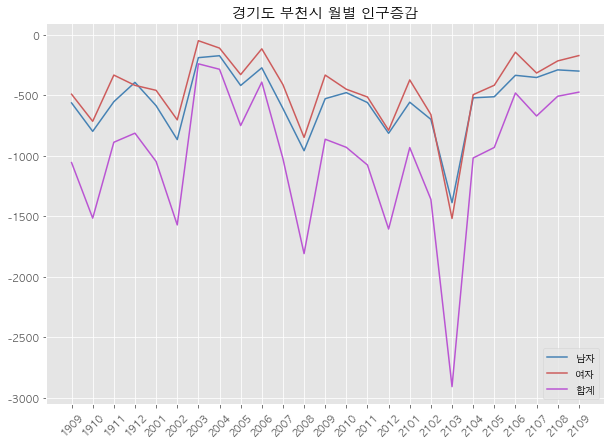

In [98]:
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 7)
plt.title('경기도 부천시 월별 인구증감')

plt.plot(ind, m, color='steelblue', label='남자')
plt.plot(ind, fm, color='indianred', label='여자')
plt.plot(ind, al, color='mediumorchid', label='합계')
plt.xticks(ind, rotation=45)
plt.legend(loc=4)
plt.show()

- 모든 달에서 인구가 감소하고 있어 감소만 보기로 하였고, 성별 차이를 잘 나타내기 위해 남녀간 인구 감소의 차이를 계산하여 막대그래프로 나타내었다.
- 막대 그래프로 나타냄에 따라 전반적으로 남자의 인구 감소가 여자보다 높다는 것을 시각적으로 잘 알 수 있다.

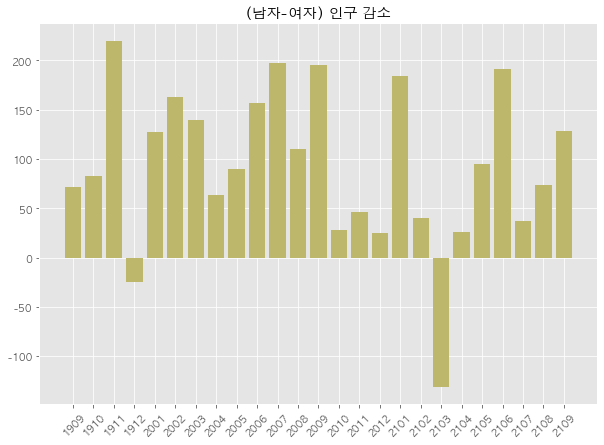

In [99]:
result = []
for i in range(len(ind)):
    mt = -m[i]
    fmt = -fm[i]
    result.append(mt - fmt)
    
plt.title('(남자-여자) 인구 감소')
plt.bar(ind, result, color='darkkhaki')
plt.xticks(ind, rotation=45)
plt.show()

#### `city`변수만 변경하고 위의 코드를 그대로 사용한다면 다른 도시의 인구증감 그래프도 그릴 수 있다!

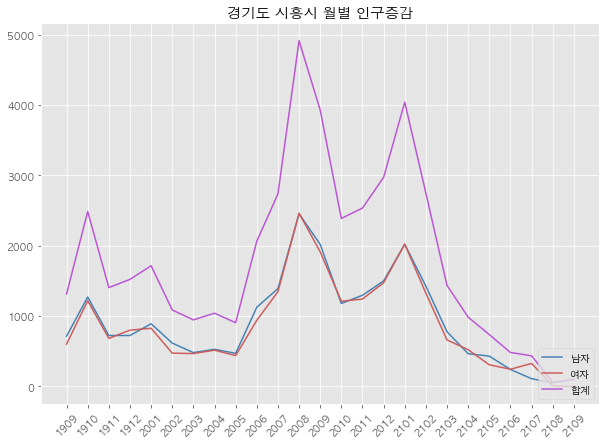

In [100]:
city = df.loc['경기도 시흥시 ']

m, fm, al = [], [], []
for i in range(len(df.columns)):
    if i % 3 == 0:
        m.append(city[i])
    elif i % 3 == 1:
        fm.append(city[i])
    else:
        al.append(city[i])
df_city = pd.DataFrame({'남자': m, '여자': fm, '합계': al}, index=ind)

plt.title('경기도 시흥시 월별 인구증감')
plt.plot(ind, m, color='steelblue', label='남자')
plt.plot(ind, fm, color='indianred', label='여자')
plt.plot(ind, al, color='mediumorchid', label='합계')
plt.xticks(ind, rotation=45)
plt.legend(loc=4)
plt.show()

### 2번. *html 안의 테이블 데이터* 읽기 & 그래프 그리기
#### 1. 데이터 설명
- [출처 URL](https://ko.wikipedia.org/wiki/%ED%94%84%EB%A6%AC%EB%AF%B8%EC%96%B4%EB%A6%AC%EA%B7%B8) : 위키피디아 > 프리미어리그 > **구단별 우승 횟수**
- 프리미어리그(epl)의 구단들 중 우승 기록이 있는 구단들의 1위, 2위 횟수 테이블이다.(efl 포함한 횟수)

#### 2. 데이터 선택 이유
- 요즘 프리미어리그를 즐겨 보고 있다. 특히 맨시티(맨체스터 시티)와 리버풀 경기를 즐겨보는데, 맨시티 vs 리버풀 경기는 어느 팀을 응원할지 항상 고민이 된다. 나는 강한 구단을 좋아하므로 실제로 어느 팀이 명성이 높은지 우승, 준우승 횟수를 비교해보고, 다른 구단들도 함께 보고 싶다.
- 질문: 맨체스터 시티와 리버풀 중 어느 구단이 우승, 준우승 횟수가 많을까? 그리고 나머지 구단들의 우승, 준우승 횟수도 함께 살펴보자.

#### 3. 데이터 전처리 내용
- 위키피디아-프리미어리그에 많은 테이블이 있다. 내가 원하는 테이블은 6번째에 있으니 df[5]를 했고, 불필요한 구단별 우승연도는 제거하였다.
- columns를 '우승', '준우승' 에서 '1위', '2위'로 간단하게 변경하였다.
- 이미 1위 순으로 정렬이 되어있어서 정렬은 생략하였고 상위 15개 구단만 살펴보겠다.

In [180]:
url = "https://ko.wikipedia.org/wiki/%ED%94%84%EB%A6%AC%EB%AF%B8%EC%96%B4%EB%A6%AC%EA%B7%B8" 
dff = pd.read_html(url, header=0, index_col=0)
dff = dff[5].iloc[:15, :2]
dff.columns = ['1위', '2위']
dff

,1위,2위
클럽,,
맨체스터 유나이티드,20,17
리버풀,19,14
아스널,13,9
에버턴,9,7
애스턴 빌라,7,10
맨체스터 시티,7,6
선덜랜드,6,5
첼시,6,4
뉴캐슬 유나이티드,4,2


- 비교하고 싶은 두 구단을 골라내었다.

In [168]:
dex = []
for i in range(len(dff.index)):
    dex.append(dff.index[i])
del dex[1], dex[4]

table = dff.drop(dex)
table

,1위,2위
클럽,,
리버풀,19,14
맨체스터 시티,7,6


#### 4. 그래프 결과 해석
- 1위, 2위를 한 횟수를 구단별로 잘 나타내기 위해 막대그래프로 나타내었다.
- 1위를 가장 많이 한 팀은 '맨체스터 유나이티드'이다. 이어서 '리버풀', '아스널', '에버턴', '애스턴빌라', '맨체스터 시티' 순이다.
- 2위는 '맨유', '리버풀', '애스턴빌라', '아스널' 순이다.

<AxesSubplot:xlabel='클럽'>

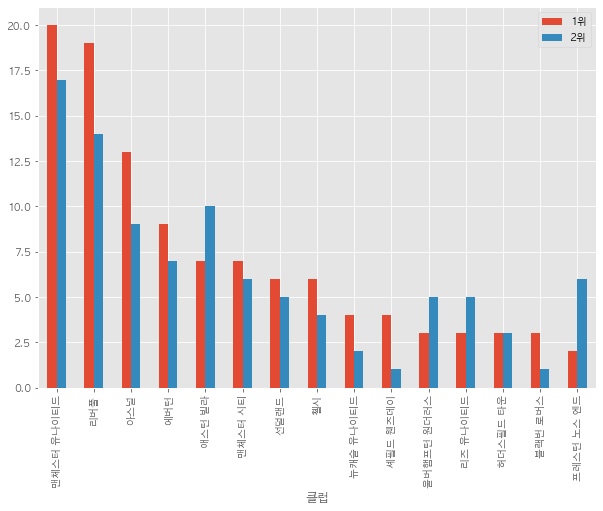

In [174]:
dff.plot(kind='bar')

- 궁금한 두 구단을 비교하기 위해 직관적인 파이 차트를 이용하였다.
- '맨시티'와 '리버풀' 중 '리버풀'이 우승, 준우승 횟수가 모두 많으므로 다음 '맨시티 vs 리버풀' 경기는 '리버풀'을 응원하기로 결정하였다!

array([<AxesSubplot:ylabel='1위'>, <AxesSubplot:ylabel='2위'>], dtype=object)

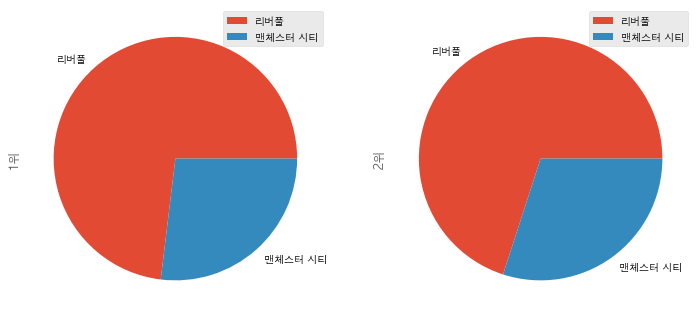

In [182]:
table.plot(kind='pie', subplots=True)

#### + plt.bar() 로도 그려보았다.

In [177]:
ylist = []
for i in range(max(max(dff.iloc[:, 0]), max(dff.iloc[:, 1]))+1):
    ylist.append(i)
ylist

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

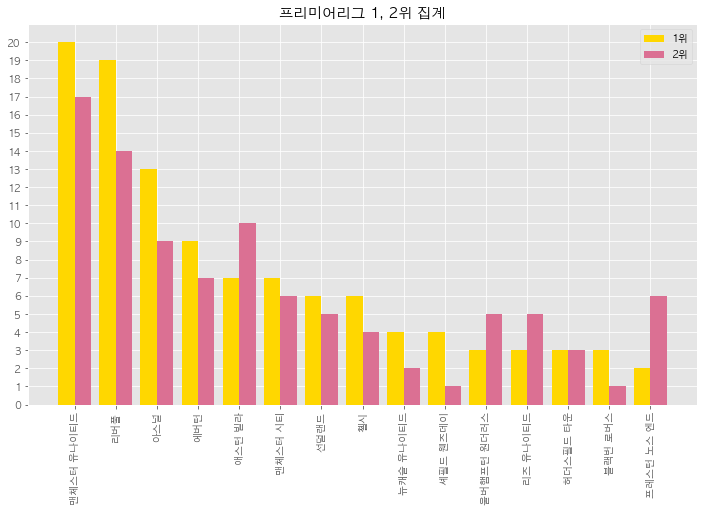

In [179]:
plt.rc('font', family='AppleGothic')
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 7)
plt.title('프리미어리그 1, 2위 집계')

x = np.arange(len(dff.index))
plt.bar(x-0.2, dff.iloc[:, 0], width=0.4, color='gold', label='1위')
plt.bar(x+0.2, dff.iloc[:, 1], width=0.4, color='palevioletred', label='2위')

plt.xticks(x, dff.index, rotation=90)
plt.yticks(ylist)
plt.legend()
plt.show()